<h1 style="font-family:Arial; font-size:26pt; font-weight:bold; text-align:center; color:#1a1a1a;">
MSCA 681 – Assignment 2
</h1>

<hr style="height:2px;border:none;color:#333;background-color:#333;" />

<h3 style="font-family:Arial; font-size:16pt; text-align:center; color:#2c3e50;">
<b>Rameeza Azhar</b> (40308895) <br>
<b>Thaer Berrached</b> (40187757) <br>
<b>Sarbjit Choong</b> (40259759)<br>

</h3>

<h4 style="font-family:Arial; font-size:14pt; text-align:center; color:#2c3e50;">
Professor <b>Mohsen Farhadloo, Ph.D</b>
</h4>


### Imported Libraries

In [1]:
# Library to analyze data
import pandas as pd
import numpy as np

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Libraries for modelling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV
import random

<h1 style="font-family:Arial; font-size:22pt; font-weight:bold; color:#2c3e50;">
a. Data preparation and exploration (20 points)
</h1>

<h4 style="font-family:Arial; font-size:12pt; text-align:left; color:#0000FF;">
1) Explore and visualize the dataset.

In [2]:
# Importing the dataset and loading the first 5 rows.
df = pd.read_csv('Carseats.csv')

#dropping extra column/ index column
df = df.drop(["Unnamed: 0"], axis=1)

# Display first 5 rows
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Carseats.csv'

<h3><span style="color:red;">Explanation:</span></h3>

**We imported the Carseat dataset. During the data review, we identified an extra index column (Unnamed: 0) that was automatically generated during data export. Since it does not contribute any meaningful information to our analysis, we decided to remove it from the dataset.**

<h4 style="font-family:Arial; font-size:12pt; text-align:left; color:#0000FF;">
1) Look into dataset structure, missing values, summary
statistics.
</h4>

In [3]:
# Checking all columns if they are identical to the ones presented in the requirements.

df.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

In [4]:
# Checking data structure, missing values,

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


<h3><span style="color:red;">Explanation:</span></h3>

**The dataset contains 400 rows and 11 columns. It includes one floating-point variable (Sales), seven integer variables (CompPrice, Income, Advertising, Population, Price, Age, Education), and three categorical variables (ShelveLoc, Urban, and US).**

**All columns have 400 non-null entries, meaning there are no missing values in the dataset. The Urban and US columns are binary categorical variables.**

In [5]:
# Checking for summary statistics

df.describe()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500,13.900000
std,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297,2.620528
min,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000,10.000000
25%,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000,12.000000
50%,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000,14.000000
75%,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000,16.000000
max,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000,18.000000


<h3><span style="color:red;">Explanation:</span></h3>

**Here is our takeaway after checking the statistical summary of each numerical column:**

- **"Sales"** has a mean of 7.50 and a STD of 2.82. The STD being smaller than the mean means that sales values are moderately spread around the average.

- **"CompPrice"** has a mean of 124.98 and a STD of 15.33. The smaller STD compared to the mean shows competitor pricing is fairly consistent across stores.

- **"Income"** has a mean of 68.66 and a STD of 27.99. The large STD relative to the mean means income levels vary widely across regions.

- **"Advertising"** has a mean of 6.64 and a STD of 6.65. The mean being close to the STD indicates large variation in advertising budgets.

- **"Population"** has a mean of 264.84 and a STD of 147.38. The large STD relative to the mean suggests store locations differ greatly in population size.

- **"Price"** has a mean of 115.80 and a STD of 23.68. The STD being smaller than the mean shows prices are relatively consistent, with moderate variation.

- **"Age"** has a mean of 53.32 and a STD of 16.20. The moderate STD suggests a fairly balanced age distribution across customers.

- **"Education"** has a mean of 13.90 and a STD of 2.62. The small STD indicates education levels are quite consistent overall.

<h4 style="font-family:Arial; font-size:12pt; text-align:left; color:#0000FF;">
1) Create at least 5 histograms, 5 box plots, 5 bar charts, 5 scatterplots using the
numerical and categorical input variables and the output variable in your dataset.
Comment on each plot based on your observations and interpretations. 
statistics.
</h4>

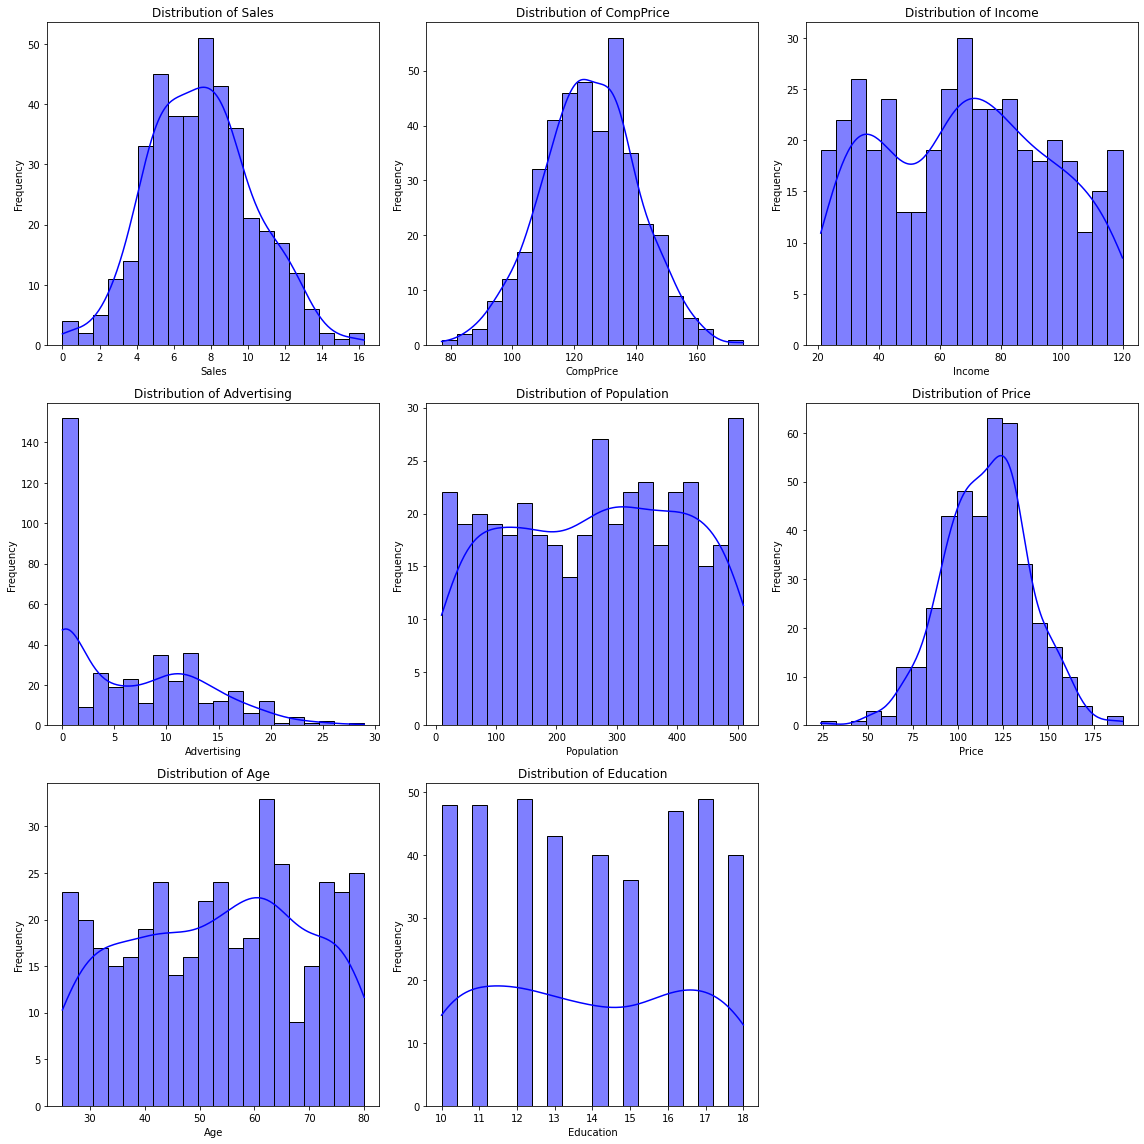

In [6]:
# ------------------------
# Histograms for numerics
# ------------------------

numeric_cols = ["Sales", "CompPrice", "Income", "Advertising", 
                "Population", "Price", "Age", "Education"]

fig, axes = plt.subplots(3, 3, figsize=(16, 16))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=20, ax=axes[i], color="blue", kde=True)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

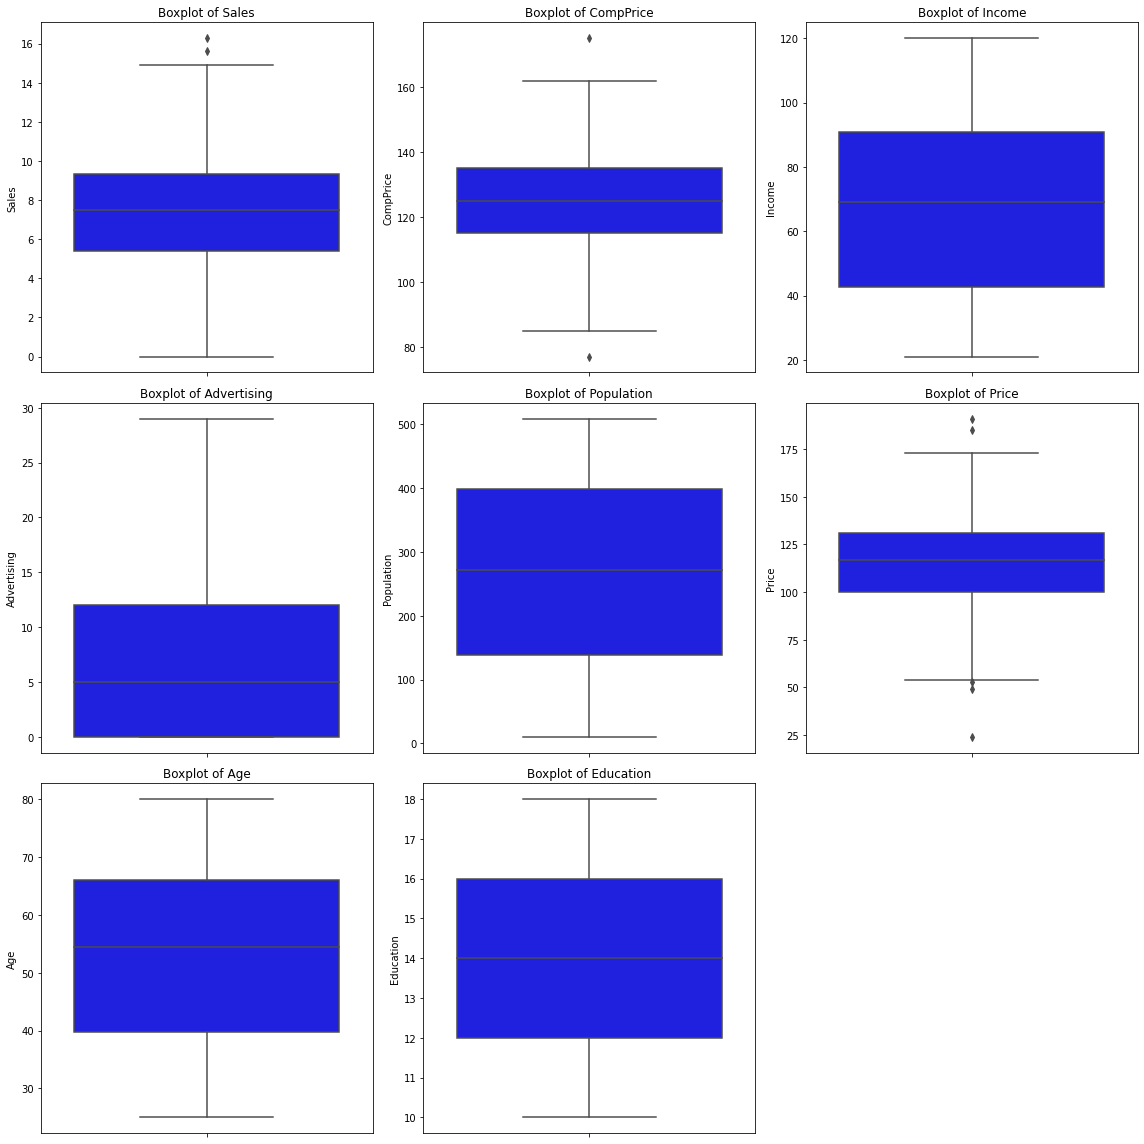

In [7]:
# ------------------------
# Boxplots for numerics
# ------------------------

fig, axes = plt.subplots(3, 3, figsize=(16, 16))
axes = axes.ravel()


for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="blue")
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_ylabel(col)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

<h3><span style="color:red;">Explanation:</span></h3>

#### The histograms and boxplots show data distribution for the numerical variables
**["Sales", "CompPrice", "Income", "Advertising", "Population", "Price", "Age", "Education"]**

1. **Sales** - The distribution shows a general normal trend. Most of the stores have sales between 5 and 10 thousand dollars. The outliers are sales from 13 to 16 thousand dollars on the boxplot. 
2. **CompPrice** - The data follows a near-normal distribution, mainly between 77 and 175. We believe that the outliers are those stores priced at 77 and 175, which stand out as unusually low and high competitor prices compared to the rest. CompPrice also has the highest frequency around 130 at the centre.
3. **Income** - The distribution is fairly uniform between 20 and 120 thousand dollars. The spread is wide, but there are no clear outliers on the boxplot. The stores operate in regions with both low- and high-income households.
4. **Advertising** - The histogram is highly right-skewed, with most stores spending less than 5 thousand dollars, and some spending 20–29 thousand dollars, which show as strong outliers. This highlights uneven marketing efforts, as only a few stores dedicate substantial budgets to advertising.
5. **Population** -Population - The data is fairly uniform, covering values from 10 to 509 thousand. This shows that stores serve areas with very different population sizes, and also, there were no outliers.
6. **Price** - The data seem to have a normal distribution with a very light tail. The data is mainly between 77 and 175. We believe that the outliers are those stores priced at 24 and 191, which stand out as unusually low and high prices compared to the rest. The outliers are the stores priced at 24 and 191, as they deviate from the main pricing range.
7. **Age** - The histogram shows almost a uniform distribution across 25 to 80 years. This means that there is a mix of younger and older customer bases. The boxplot confirms no outliers.
8. **Education** - The distribution is slightly left-skewed, ranging from 10 to 18 years. Most observations cluster around 13–16, with no outliers. This shows the high and low levels of the education group.

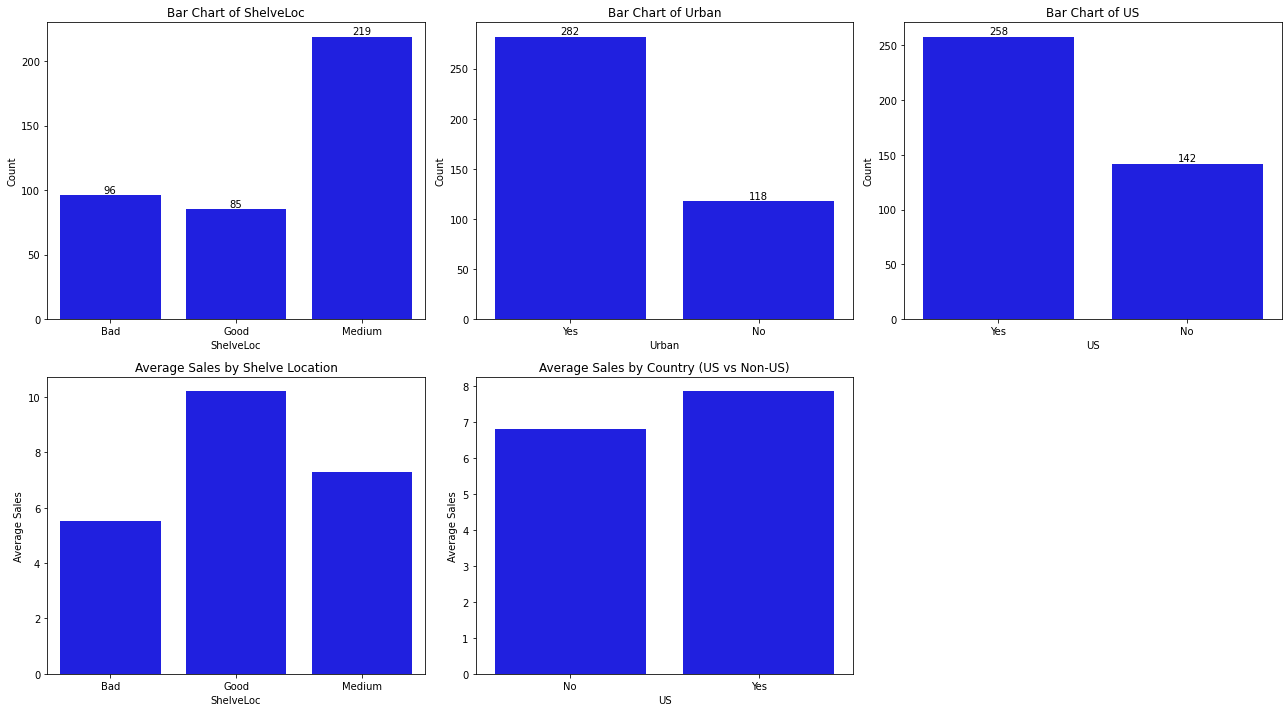

In [8]:
# ------------------------
# Barcharts for categorical columns
# ------------------------

cat_cols = ["ShelveLoc", "Urban", "US"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    sns.countplot(x=df[col], ax=axes[i], color="blue")
    axes[i].set_title(f"Bar Chart of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].bar_label(axes[i].containers[0])


avg_sales_shelve = df.groupby("ShelveLoc")["Sales"].mean().reset_index()
sns.barplot(x="ShelveLoc", y="Sales", data=avg_sales_shelve, ax=axes[3], color="blue")
axes[3].set_title("Average Sales by Shelve Location")
axes[3].set_xlabel("ShelveLoc")
axes[3].set_ylabel("Average Sales")


avg_sales_us = df.groupby("US")["Sales"].mean().reset_index()
sns.barplot(x="US", y="Sales", data=avg_sales_us, ax=axes[4], color="blue")
axes[4].set_title("Average Sales by Country (US vs Non-US)")
axes[4].set_xlabel("US")
axes[4].set_ylabel("Average Sales")


fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

<h3><span style="color:red;">Explanation:</span></h3>

#### Bar charts are typically used to represent categorical variables which shows the frequency or proportion of each category. We used them to display the distribution of our categorical columns - ["ShelveLoc", "Urban", and "US"].

**Since the assignment required five bar charts, we also added average sales by shelf location and average sales by country to explore how these factors relate to sales performance.**

1. **ShelveLoc** - The majority of stores (54.75%) have a Medium shelf location, followed by Bad (24%) and Good (21.25%). This shows that most stores have average product placement. Also, the distribution is imbalanced, with most stores classified as Medium
2. **CompPrice** - About 70.5% of stores are located in urban areas, while 29.5% are in non-urban regions. The distribution is skewed, as Urban stores dominate.
3. **US** - Roughly 64.5% of stores are based in the US, while 35.5% operate outside the US. This shows a stronger representation of US markets. Also, the distribution is slightly uneven with more stores in the US.
4. **Average Sales by ShelveLoc** - Stores with a Good shelf location show the highest average sales, followed by Medium and Bad. This pattern confirms that better shelf placement is linked to higher sales performance. The distribution shows increasing sales from Bad to Good locations.
5. **Average Sales by Country (US)** - US-based stores record higher average sales compared to non-US stores, suggesting that domestic stores perform slightly better. The distribution shows higher average sales in US stores.


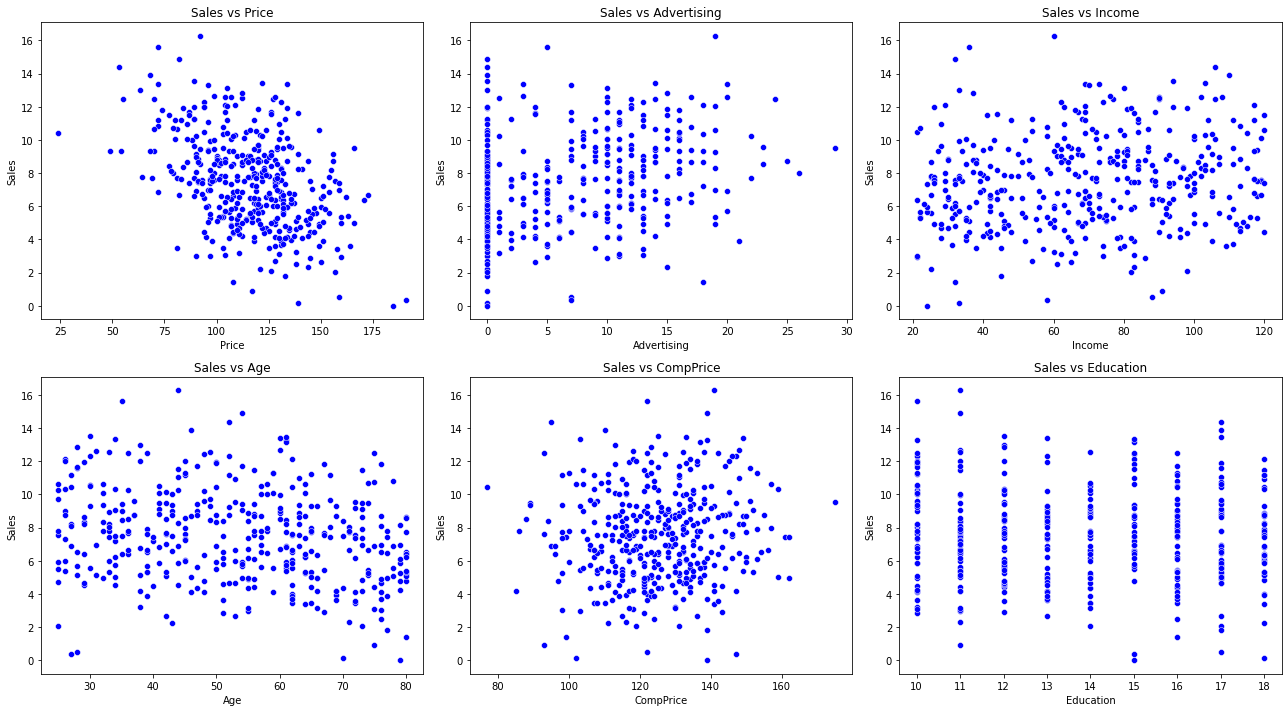

In [9]:
# -------------------------------
# Scatterplots for relationships
# ------------------------------

scatter_pairs = [("Price", "Sales"), ("Advertising", "Sales"), ("Income", "Sales"),
                 ("Age", "Sales"),("CompPrice", "Sales"), ("Education", "Sales")]

fig, axes = plt.subplots(2,3, figsize=(18, 10))
axes = axes.ravel()

for i, (x, y) in enumerate(scatter_pairs):
    sns.scatterplot(x=df[x], y=df[y], ax=axes[i], color="blue")
    axes[i].set_title(f"{y} vs {x}")
    axes[i].set_xlabel(x)
    axes[i].set_ylabel(y)


plt.tight_layout()
plt.show()

<h3><span style="color:red;">Explanation:</span></h3>

#### We created scatterplots to explore the relationships between the output variable (Sales) and key numerical predictors.  Since "Sales" is our target variable, we have decided to examine predictors that are most likely to influence it and these are - ["Price" , "Advertising", "Income", "Age", and "CompPrice", "Education"]. 
These variables were chosen because they reflect important factors such as customer spending, marketing investment, advertising campaign effectiveness, and competitive pricing.

1. **Sales and Price** - The scatterplot shows a clear negative trend where sales decline as prices rise. This means that higher pricing may limit purchases from buying.
2. **Sales and Advertising** - There appears to be a positive relationship, meaning stores that spend more on advertising generally see higher sales.
3. **Sales and Income** - The points show a slightly upward pattern. This could mean that higher income households tend to have somewhat higher sales.
4. **Sales and Age** - The data appears very scattered which shows no clear relationship between the customer age and sales. This could mean that age is not a significant factor that drives sales.
5. **Sales and CompPrice** - The data points are mostly concentrated in the middle, showing no strong linear relationship between competitor pricing and sales.
6. **Sales and Education** - The data points do not show any correlation with Sales.

<h3 style="color:#0000FF;">2) Examine relationships between numerical variables.
Identify highly correlated variables with each other and with the target. Discuss whether these variables should be dropped or not, considering the type of models you will use later.
</h3>

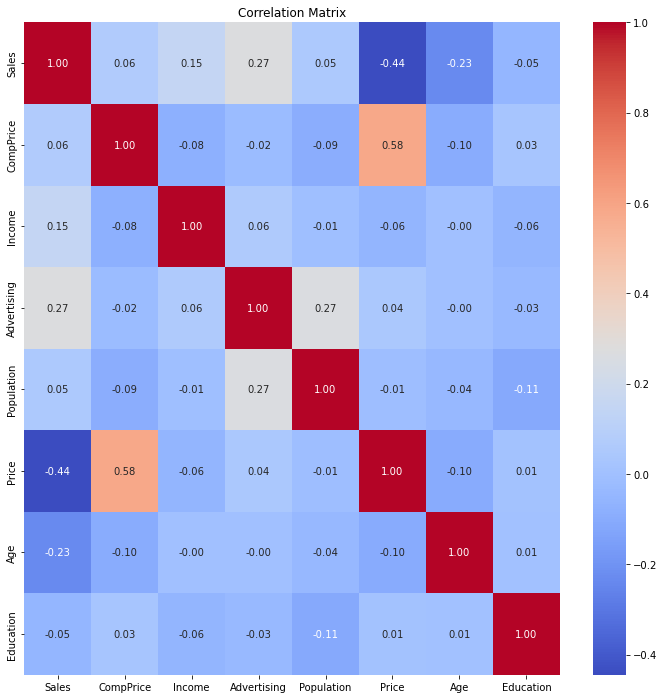

In [10]:
# Adding a correlational matrix to check for multicollinearity

numeric_cols = ["Sales", "CompPrice", "Income", "Advertising", 
                "Population", "Price", "Age", "Education"]

# SELECT only numeric columns before calculating correlation
corr = df[numeric_cols].corr()

# Show the correlation matrix with a heatmap    
plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Matrix")     
plt.show()


In [11]:
# Identify highly correlated pairs (|r| > 0.7)

threshold = 0.7
high_corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index())
high_corr_pairs.columns = ["Variable 1", "Variable 2", "Correlation"]
high_corr_pairs = high_corr_pairs[high_corr_pairs["Correlation"].abs() > threshold]

print("\nHighly Correlated Variable Pairs (|r| > 0.7):\n")
print(high_corr_pairs if not high_corr_pairs.empty else "No highly correlated pairs found.")


Highly Correlated Variable Pairs (|r| > 0.7):

No highly correlated pairs found.


<h3><span style="color:red;">Explanation:</span></h3>

#### We calculated the correlation matrix to explore the relationships among all numerical variables in the dataset. This made us understand how strongly the variables are related to one another and to the target variable (Sales). 

#### To identify highly correlated pairs, we used a threshold of |r| > 0.7. This threshold is commonly applied in statistical analysis since correlations above 0.7 (or below -0.7) are considered strong.

#### After we applied the code, we learned that none of the numerical variables are strongly correlated with each other. This means each predictor provides unique information to the dataset. As a result, there’s no concern about redundancy, and all variables can be safely included in modeling without the risk of multicollinearity.

<h3 style="color:#0000FF;">3) Convert categorical variables into numeric form using dummy variables. 
</h3>

In [12]:
categorical = ["ShelveLoc", "Urban", "US"]

df_new = pd.get_dummies(df, columns=categorical, drop_first=True)

# Check if it worked
df_new.head()


,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_Good,ShelveLoc_Medium,Urban_Yes,US_Yes
0,9.50,138,73,11,276,120,42,17,0,0,1,1
1,11.22,111,48,16,260,83,65,10,1,0,1,1
2,10.06,113,35,10,269,80,59,12,0,1,1,1
3,7.40,117,100,4,466,97,55,14,0,1,1,1
4,4.15,141,64,3,340,128,38,13,0,0,1,0


In [13]:
# Checking for datatypes.

df_new.dtypes

Sales               float64
CompPrice             int64
Income                int64
Advertising           int64
Population            int64
Price                 int64
Age                   int64
Education             int64
ShelveLoc_Good        uint8
ShelveLoc_Medium      uint8
Urban_Yes             uint8
US_Yes                uint8
dtype: object

<h3><span style="color:red;">Explanation:</span></h3>

#### After converting the categorical variables into dummy variables, all the data is now in numerical form. The newly created dummy columns are stored as uint8 data types because they only contain 0s and 1s. Since the range of uint8 (0–255) easily covers our binary values, pandas automatically assigns this smaller and more efficient data type instead of a regular integer.

<h3 style="color:#0000FF;">4) Partition the data into a training set (60%), validation set (20%), and test set (20%) (set
random_state=42). 
</h3>

In [14]:
# Define target and predictors

y = df_new["Sales"]
X = df_new.drop(columns=["Sales"],axis=1)
print("X is", X.shape)
print("y is", y.shape)

X is (400, 11)
y is (400,)


In [15]:
# First split: separate out training set (60%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.6,random_state=42)

# Second split: split the remaining 40% into validation (20%) and test (20%)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5,random_state=42)

# Check shapes
print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

Training set shape: (240, 11)
Validation set shape: (80, 11)
Test set shape: (80, 11)


In [16]:
print("Features in training set:")
print(X_train.columns.tolist())
print(f"\nTotal: {len(X_train.columns)} features")

n_train = 240
n_features = 11

print("=== VERIFICATION ===")
print(f"Training samples: {n_train}")
print(f"Number of features: {n_features}")
print()

Features in training set:
['CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'Age', 'Education', 'ShelveLoc_Good', 'ShelveLoc_Medium', 'Urban_Yes', 'US_Yes']

Total: 11 features
=== VERIFICATION ===
Training samples: 240
Number of features: 11



<h3><span style="color:red;">Explanation:</span></h3>

#### First, we identified our y variable, which is “Sales”, and our X variables are ['CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'Age', 'Education', 'ShelveLoc_Good', 'ShelveLoc_Medium', 'Urban_Yes', 'US_Yes']. We then partitioned our data into a training set (240 rows and 11 columns), a validation set (80 rows and 11 columns), and a test set (80 rows and 11 columns)

We then split the data into training and a temporary set which will later be used to split between validation and test data. We used test_size=0.5 to split the remaining 40% in half, giving us two equal parts of 20% each for validation and testing.

<hr style="height:2px;border:none;color:#333;background-color:#333;" />

<h1 style="font-family:Arial; font-size:22pt; font-weight:bold; color:#2c3e50;">
b. Train a Random Forest Regressor to predict Sales. (from sklearn.ensemble import
RandomForestRegressor) (20 points)
</h1>

<h3 style="color:#0000FF;">1.) What are the hyper parameters of this model that can be tuned? (Check the
documentation of this model from scikitlearn).
</h3>

<h3><span style="color:red;">Explanation:</span></h3>

#### There are several hyperparameters that can be tuned for this Random Forest Regressor but the key hyperparameters are found below.

#### Hyperparameter Selection Justification: 
1. **n_estimators: [100, 200, 300]** 
<br>This hyperparameter sets how many trees the model will build.
We will test a range of tree counts to balance model performance and computational cost. With 240 training samples and 11 features, 100-300 trees provide sufficient ensemble diversity without excessive training time. </br>

2. **max_depth: [3, 5, 7, 9]**
<br>This hyperparameter limits the maximum depth of each tree; helps control model complexity.
We will limit tree depth to prevent overfitting given our moderate dataset size (240 samples). Shallow trees (3-5) provide strong regularization, while moderate depths (7-9) allow capturing more complex interactions. We excluded deeper trees (>10) and unlimited depth to avoid memorizing training data. </br>

3. **min_samples_leaf: [0.01, 0.02]**
<br>This hyperparameter sets the minimum number of samples needed to be at a leaf node.
We will use 1% and 2% of training data (approximately 2-5 samples per leaf) to control tree complexity. Using fractions rather than absolute numbers ensures the constraint scales appropriately with dataset size. These values prevent overfitting by requiring meaningful sample sizes in leaf nodes while not being so restrictive as to cause underfitting. </br>

4. **max_features: ['sqrt', 'log2']**
<br>This hyperparameter decides how many features to consider when looking for the best split.
With 11 features total, sqrt considers √11 ≈ 3.3 features per split, while log2 considers log₂(11) ≈ 3.5 features. Both options introduce randomness and feature diversity across trees, which improves generalization. </br>

5. **criterion: ['squared_error', 'friedman_mse']**
<br> This hyperparameter determines how the model measures the quality of a split (e.g., squared_error, friedman_mse, and many more). We will compare the two regression criteria: standard mean squared error (MSE) and Friedman's MSE with improvement score. While typically showing minimal performance differences, testing both ensures we select the optimal split quality measure for our specific data distribution. </br>

Other hyperparameters that can be used are: **min_samples_split, min_weight_fraction_leaf, max_leaf_nodes, min_impurity_decrease, bootstrap, oob_score, n_jobs, random_state, verbose, warm_start, ccp_alpha, max_samples, monotonic_cst.**

6. **min_samples_split** - specifies the minimum number of samples required to split an internal node.

7. **min_weight_fraction_leaf** – sets the minimum weighted fraction of the total samples required to be at a leaf node.

8. **max_leaf_nodes** – limits the number of leaf nodes in each tree.

9. **min_impurity_decrease** – a node will split only if the impurity decrease is greater than or equal to this value.

10. **bootstrap** – determines whether bootstrap samples are used when building trees.

11. **oob_score** – enables out-of-bag samples to estimate model performance.

12. **n_jobs** – controls how many CPU cores are used for parallel processing.

13. **random_state** – ensures reproducibility of results.

14. **verbose** – controls the level of printed output during training.

15. **warm_start** – allows the model to reuse previous trees and add more.

16. **ccp_alpha** – used for minimal cost-complexity pruning.

17. **max_samples** – if bootstrap is True, this sets the number (or fraction) of samples drawn from the dataset to train each tree.

18. **monotonic_cst** – allows imposing monotonic constraints on features.

<h3 style="color:#0000FF;">2.) Tune at least two hyperparameters using cross validation.
</h3>

In [17]:
# define the hyperparameters to tune

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'min_samples_leaf': [0.01, 0.02],                
    'max_features': ['sqrt', 'log2'],
    'criterion': ['squared_error', 'friedman_mse']}
 
   # Total: 3 × 4 × 2 × 2 = 96 combinations
   
# Create a Random Forest Regressor
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Create a GridSearchCV object (use a regression metric)
gs = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    return_train_score=True,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=0)

gs.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'criterion': ['squared_error', 'friedman_mse'],
                         'max_depth': [3, 5, 7, 9],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [0.01, 0.02],
                         'n_estimators': [100, 200, 300]},
             return_train_score=True, scoring='neg_mean_squared_error')

In [18]:
# Getting the best parameters from the model
m_rf = gs.best_estimator_

print("Best parameters:", gs.best_params_)

Best parameters: {'criterion': 'squared_error', 'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 0.01, 'n_estimators': 200}


<h3><span style="color:red;">Explanation:</span></h3>

### Hyperparameter Selection Justification

**Our best parameters are: {'criterion': 'squared_error', 'max_depth': 9, 'max_features': 'sqrt', 'min_samples_leaf': 0.01, 'n_estimators': 200}.**

We tuned 5 hyperparameters, resulting in **96 total combinations** (3 × 4 × 2 × 2 × 2). Our selections were based on the following rationale:

1. **n_estimators: [100, 200, 300]**
We tested different numbers of trees to balance performance and training time. With 240 samples and 11 features, 200 trees provided strong ensemble performance without unnecessary computational cost. Fewer trees (<100) risked underfitting, while more than 300 offered minimal improvement.
2. **max_depth: [3, 5, 7, 9]**
We limited tree depth to control model complexity and reduce overfitting. The best-performing model used a depth of 9, which captures meaningful feature interactions while maintaining generalization. Depths beyond 10 were excluded to prevent memorization of the training data.
3. **min_samples_leaf: [0.01, 0.02]**
We set the minimum samples per leaf as a fraction of the training data to ensure scalability. The optimal value of 0.01 (≈2–3 samples per leaf) prevents overly specific leaves while still allowing flexibility in the splits.
4. **max_features: ['sqrt', 'log2']**
With 11 total features, using 'sqrt' means approximately √11 ≈ 3.3 features are considered at each split. This introduces randomness and reduces correlation between trees, improving generalization. It was slightly better than 'log2' in validation performance.
5. **criterion: ['squared_error', 'friedman_mse']**
We compared two splitting criteria: standard mean squared error (MSE) and Friedman’s MSE. The model performed best with 'squared_error', indicating standard variance reduction yielded more stable splits for this dataset.

This was a moderate resources model considering the time and cost constraints.


<h3 style="color:#0000FF;">3.) Evaluate the performance of the model on the validation and test sets using MAE and RMSE.
</h3>

In [19]:
# Predict on validation and test sets

y_val_pred = m_rf.predict(X_val)
y_test_pred = m_rf.predict(X_test)

# Calculate metrics
mae_val = mean_absolute_error(y_val, y_val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))

mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Validation MAE: {mae_val:.3f}")
print(f"Validation RMSE: {rmse_val:.3f}")
print(f"Test MAE: {mae_test:.3f}")
print(f"Test RMSE: {rmse_test:.3f}")

# ---- Store under RF-specific names for later comparison ----
mae_val_rf   = mae_val
rmse_val_rf  = rmse_val
mae_test_rf  = mae_test
rmse_test_rf = rmse_test

Validation MAE: 1.445
Validation RMSE: 1.894
Test MAE: 1.495
Test RMSE: 1.798


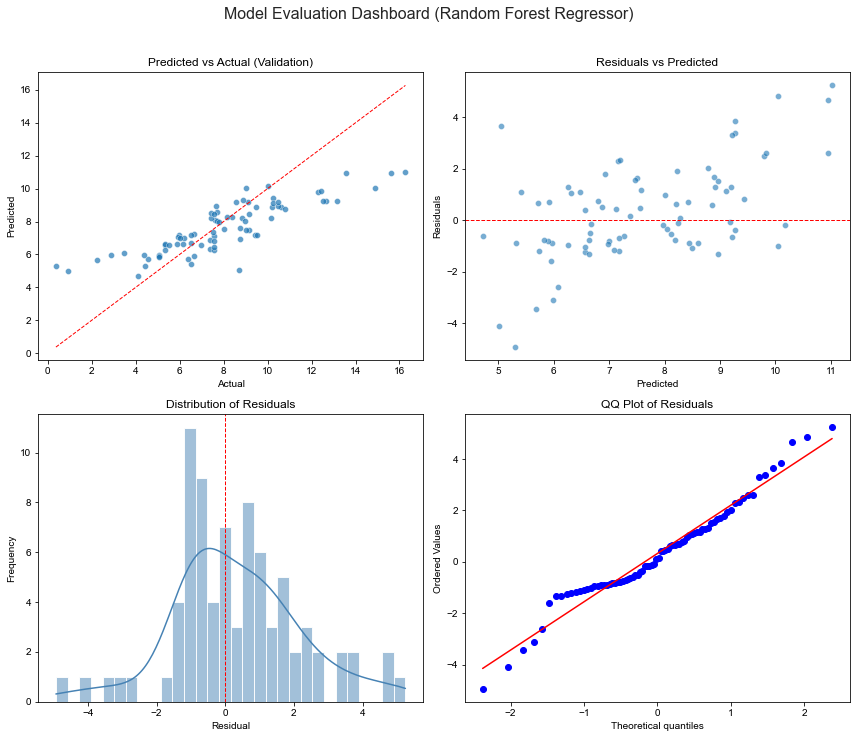

In [20]:
# 1) Predict on validation set
y_val_pred = m_rf.predict(X_val)
residuals_val = y_val - y_val_pred

# If y_val is a pandas Series, convert to numpy for min/max
y_val_np = np.asarray(y_val)

# 2) Plot dashboard
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
sns.set_style("whitegrid")

# (a) Predicted vs Actual
sns.scatterplot(ax=axes[0, 0], x=y_val_np, y=y_val_pred, alpha=0.7)
min_val = np.min([y_val_np.min(), y_val_pred.min()])
max_val = np.max([y_val_np.max(), y_val_pred.max()])
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
axes[0, 0].set_title('Predicted vs Actual (Validation)')
axes[0, 0].set_xlabel('Actual')
axes[0, 0].set_ylabel('Predicted')

# (b) Residuals vs Predicted
sns.scatterplot(ax=axes[0, 1], x=y_val_pred, y=residuals_val, alpha=0.6)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0, 1].set_title('Residuals vs Predicted')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Residuals')

# (c) Distribution of Residuals
sns.histplot(ax=axes[1, 0], data=residuals_val, kde=True, bins=30, color='steelblue')
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].set_xlabel('Residual')
axes[1, 0].set_ylabel('Frequency')

# (d) QQ Plot of Residuals
stats.probplot(residuals_val, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('QQ Plot of Residuals')

plt.suptitle("Model Evaluation Dashboard (Random Forest Regressor)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

<h3><span style="color:red;">Explanation:</span></h3>

#### We used MAE and RMSE to evaluate the model’s accuracy. MAE measures the average absolute difference between predicted and actual sales, while RMSE gives more weight to larger errors.

#### The model achieved a Validation MAE of 1.445 and RMSE of 1.894, and a Test MAE of 1.495 and RMSE of 1.798. The close values across both test and validation show that the model performs consistently and will be able to generalize well with unseen. Overall, predictions are fairly accurate with small errors and no clear signs of overfitting.

#### Graph: 
We decided to plot the outcomes to see how well our Random Forest model performed and to check if there were any visible patterns or issues with the predictions. Here’s what we found out:

1. **Predicted vs Actual (top-left)** - Most of the points are close to the red dashed line, meaning the predicted sales values are quite close to the actual ones. This shows that the model is performing well and making accurate predictions.
2. **Residuals vs Predicted (top-right)** -The residuals are scattered randomly around zero with no clear pattern, which suggests that the model’s errors are spread evenly. This is a good sign because it means the model isn’t missing any major trend.
3. **Distribution of Residuals (bottom-left)** -The residuals are centered around zero and form a roughly bell-shaped curve. This means most of the errors are small and balanced on both sides, which indicates the model is predicting consistently.

4. **QQ Plot (bottom-right)** - The points mostly follow the red diagonal line, meaning the residuals are close to normally distributed. This confirms that the model’s assumptions hold and that it’s stable across different values.

**Overall, these plots show that our Random Forest Regressor fits the data well, makes reliable predictions, and doesn’t show signs of overfitting or bias.**

<h3 style="color:#0000FF;">4.) Use the feature_importance_ values to determine which variables are the most important. Comment on the top 3 predictors.
</h3>

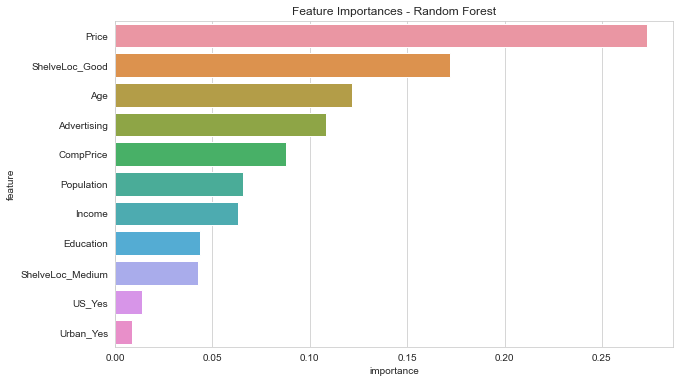

In [21]:
# Create a feature importance for the random forest model
importances = m_rf.feature_importances_

# Create a DataFrame for the feature importances
feature_importances_rf = pd.DataFrame({'feature': X_train.columns, 'importance': importances})

# Sort the DataFrame by importance
feature_importances_rf = feature_importances_rf.sort_values(by='importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importances_rf.head(20))
plt.title('Feature Importances - Random Forest')
plt.show()

In [22]:
feat_importances = pd.Series(
    m_rf.feature_importances_, 
    index=X_train.columns).sort_values(ascending=False)

print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

print("\nTop 3 Most Important Predictors:")
print("-" * 40)
for i, (feature, importance) in enumerate(feat_importances.head(3).items(), 1):
    print(f"{i}. {feature:20s}: {importance:.4f} ({importance*100:.2f}%)")

# Calculate cumulative importance
top_3_cumulative = feat_importances.head(3).sum()
print(f"\nTop 3 features explain {top_3_cumulative*100:.2f}% of total importance")


FEATURE IMPORTANCE ANALYSIS

Top 3 Most Important Predictors:
----------------------------------------
1. Price               : 0.2729 (27.29%)
2. ShelveLoc_Good      : 0.1722 (17.22%)
3. Age                 : 0.1216 (12.16%)

Top 3 features explain 56.68% of total importance


<h3><span style="color:red;">Explanation:</span></h3>

#### The x-axis shows the percentage value of each feature’s contribution to the model’s performance.
#### The top 3 predictors are:

1. **Price** - This is the most important predictor, meaning changes in price have the biggest impact on sales. It holds about 27% of the overall importance in the model. Since Price represents the cost customers pay for car seats, we believe that lower prices make the product more appealing which drives higher sales.

2. **ShelveLoc_Good** - This is the second most important feature. This supports for about 17% of the model’s importance. Since ShelveLoc measures the quality of shelf placement, stores with a “Good” shelf location likely have better product visibility which eventually leads to higher sales.

3. **Age** - This feature contributes around 12% to the model’s performance. Age represents the average age of the local population. Older communities may have more established families, which could translate into more consistent demand for child-related products like car seats.


Also, we noticed that **‘US_Yes’ and ‘Urban_Yes’** have the least importance (almost close to 0%), showing that being located in the US or in an urban area has minimal influence on sales predictions. This suggests that geographic location or store setting (urban vs. rural) doesn’t strongly impact sales outcomes.

<h1 style="font-family:Arial; font-size:22pt; font-weight:bold; color:#2c3e50;">
c. Gradient Boosting Regressor to Predict Sales (30 points)
</h1>


<h3 style="color:#0000FF;">
1.) What are the hyperparameters of this model that can be tuned? (Check the documentation of this model from scikit-learn).
</h3>

<h3><span style="color:red;">Explanation:</span></h3>

**Gradient Boosting Regressor** - This estimator builds an additive model in a forward stage-wise fashion; it allows for the optimization of arbitrary differentiable loss functions. In each stage a regression tree is fit on the negative gradient of the given loss function.

#### There are several hyperparameters that can be tuned for this Gradient Boosting Regressor:

1. **loss** - Loss function to be optimized. Options are 'squared_error', 'absolute_error', 'huber', 'quantile'.

2. **learning_rate** - Learning rate shrinks the contribution of each tree by learning_rate. There is a trade-off between learning_rate and n_estimators.

3. **n_estimators** - The number of boosting stages to perform. Gradient boosting is fairly robust to over-fitting so a large number usually results in better performance.

4. **subsample** - The fraction of samples to be used for fitting the individual base learners. 

5. **criterion** - The function to measure the quality of a split. 

6. **min_samples_split** - The minimum number of samples required to split an internal node. In the case of float, values must be in the range (0.0, 1.0] and min_samples_split will be ceil(min_samples_split * n_samples).

7. **min_samples_leaf** - For float, values must be in the range (0.0, 0.5) and min_samples_leaf will be ceil(min_samples_leaf * n_samples).

8. **min_weight_fraction_leaf** - The minimum weighted fraction of the sum total of weights (of all the input samples) required to be at a leaf node. Values must be in the range [0.0, 0.5].

9. **max_depth** - The maximum depth limits the number of nodes in the tree. 

10. **min_impurity_decrease** - A node will be split if this split induces a decrease of the impurity greater than or equal to this value. Values must be in the range [0.0, inf)

11. **init: estimator or ‘zero’, default=None** - An estimator object that is used to compute the initial predictions. init has to provide fit and predict. If ‘zero’, the initial raw predictions are set to zero.

12. **random_state** - Controls the random seed given to each Tree estimator at each boosting iteration. In addition, it controls the random permutation of the features at each split

13. **alpha, default=0.9** - The alpha-quantile of the huber loss function and the quantile loss function.

14. **verbose, default=0** - Enable verbose output. If 1 then it prints progress and performance once in a while

15. **max_leaf_nodes, default=None** - Grow trees with max_leaf_nodes in best-first fashion. Best nodes are defined as relative reduction in impurity. Values must be in the range [2, inf). 

16. **warm_start, default=False** - When set to True, reuse the solution of the previous call to fit and add more estimators to the ensemble, otherwise, just erase the previous solution.

17. **n_iter_no_change, default=None** - n_iter_no_change is used to decide if early stopping will be used to terminate training when validation score is not improving. By default it is set to None to disable early stopping. If set to a number, it will set aside validation_fraction size of the training data as validation and terminate training when validation score is not improving in all of the previous n_iter_no_change numbers of iterations. Values must be in the range [1, inf). 

18. **ccp_alpha, default=0.0** - Complexity parameter used for Minimal Cost-Complexity Pruning. The subtree with the largest cost complexity that is smaller than ccp_alpha will be chosen. By default, no pruning is performed. Values must be in the range [0.0, inf).

19. **tol, default=1e-4** - Tolerance for the early stopping. When the loss is not improving by at least tol for n_iter_no_change iterations (if set to a number), the training stops. Values must be in the range [0.0, inf).

20. **max_features** – Number/features considered when looking for the best split.

21. **validation_fraction** – Used when n_iter_no_change is set for early stopping.

#### Due to time constraints, we will tune only the key hyperparameters: n_estimators (150, 200, 250, 300), learning_rate (0.08, 0.1, 0.12, 0.15), max_depth (1, 2, 3), subsample (0.8, 0.9, 1.0), and random_state (42). These were selected because they have the largest impact on performance and training efficiency.

<h3 style="color:#0000FF;">
2.) Tune at least two hyperparameters using cross-validation.
</h3>

In [23]:
# GRID SEARCH
# ===========================================

param_grid_gbr = {
    "n_estimators": [150, 200, 250, 300],
    "learning_rate": [0.08, 0.1, 0.12, 0.15],
    "max_depth": [1, 2, 3],
    "subsample": [0.8, 0.9, 1.0],
    "random_state": [42]}

grid_gbr = GridSearchCV(
    GradientBoostingRegressor(random_state=42), param_grid_gbr,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1)

grid_gbr.fit(X_train, y_train)
best_model_gbr = grid_gbr.best_estimator_
print("Best parameters:", grid_gbr.best_params_)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best parameters: {'learning_rate': 0.15, 'max_depth': 1, 'n_estimators': 300, 'random_state': 42, 'subsample': 0.9}


<h3><span style="color:red;">Explanation:</span></h3>

### Hyperparameter Selection Justification
We tuned five hyperparameters of a Gradient Boosting Regressor using 5-fold cross-validation with negative MSE as the scoring metric. The grid contained **144 combinations** (4 × 4 × 3 × 3 × 1), resulting in **720 fits**.

Our best parameters are: **{'learning_rate': 0.15, 'max_depth': 1, 'n_estimators': 300, 'random_state': 42, 'subsample': 0.9}** This was a moderate resources model considering the time constraints.

1. **n_estimators**: 150, 200, 250, 300 - this controls the number of boosting stages. We tested different numbers of boosting stages to balance accuracy and training time. With 240 samples and 11 features, 300 estimators provided the best performance before the model began to plateau. Fewer trees (<150) led to slightly underfitted results, while adding more than 300 did not significantly improve performance.
2. **learning_rate**: 0.08, 0.10, 0.12, 0.15 — This hyperparameter shrinks each tree’s contribution, where lower values typically need more trees. This parameter controls how much each tree contributes to the overall model. The best value of 0.15 allowed the model to learn patterns efficiently without overfitting. Lower learning rates required more trees to achieve similar accuracy, while higher ones caused instability.
3. **max_depth**: 1, 2, 3  - this hyperparameter limits individual tree depth to prevent overfitting and keep learners weak (which is desirable in boosting). We kept the trees shallow to ensure weak learners, which is ideal for boosting. A depth of 1 performed best, capturing simple patterns while preventing overfitting. Deeper trees (2 or 3) slightly increased training accuracy but hurt generalization on validation data.
4. **subsample**: 0.8, 0.9, 1.0 — stochastic gradient boosting; using <1.0 can improve generalization. We introduced stochasticity by sampling a fraction of the data for each boosting stage. The best value (0.9) provided a good balance between model diversity and stability, improving generalization compared to using all data (1.0).
5. **random_state**: 42 — his ensures reproducibility of results by fixing the random seed. Using a constant seed guarantees that the model produces consistent results across runs with the same parameters and data.


This grid targets the core bias–variance levers in boosting: the learning rate / n_estimators trade-off, tree complexity via max_depth, and stochasticity via subsample. The ranges were chosen to balance model accuracy and training time given our dataset (240 samples, 11 features).


<h3 style="color:#0000FF;">
3.) Evaluate the model on the validation and test sets using MAE and RMSE.
</h3>

In [24]:
y_val_pred = best_model_gbr.predict(X_val)
mae_val = mean_absolute_error(y_val, y_val_pred)
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))

print("Validation MAE :", round(mae_val, 4))
print("Validation RMSE:", round(rmse_val, 4))

# Test
y_test_pred = best_model_gbr.predict(X_test)
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))  

print("Test MAE :", round(mae_test, 4))
print("Test RMSE:", round(rmse_test, 4))

# Store metrics for later comparison
mae_val_gbr  = mae_val
rmse_val_gbr = rmse_val
mae_test_gbr  = mae_test
rmse_test_gbr = rmse_test

Validation MAE : 0.9312
Validation RMSE: 1.1176
Test MAE : 1.0113
Test RMSE: 1.2778


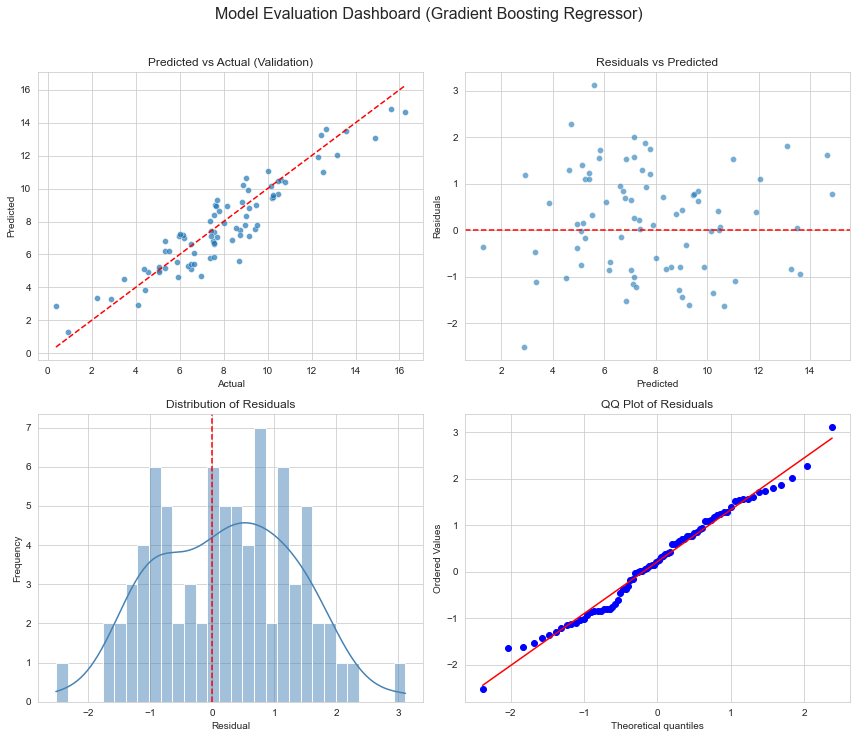

In [25]:
residuals_val = y_val - y_val_pred

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plt.subplots_adjust(hspace=0.3, wspace=0.3)
sns.set_style("whitegrid")

# 1. Predicted vs Actual
sns.scatterplot(ax=axes[0, 0], x=y_val, y=y_val_pred, alpha=0.7)
axes[0, 0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
axes[0, 0].set_title('Predicted vs Actual (Validation)')
axes[0, 0].set_xlabel('Actual')
axes[0, 0].set_ylabel('Predicted')

# 2. Residuals vs Predicted
sns.scatterplot(ax=axes[0, 1], x=y_val_pred, y=residuals_val, alpha=0.6)
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title('Residuals vs Predicted')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Residuals')

# 3. Distribution of Residuals
sns.histplot(ax=axes[1, 0], data=residuals_val, kde=True, bins=30, color='steelblue')
axes[1, 0].axvline(0, color='red', linestyle='--')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].set_xlabel('Residual')
axes[1, 0].set_ylabel('Frequency')

# 4. QQ Plot
stats.probplot(residuals_val, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('QQ Plot of Residuals')

plt.suptitle("Model Evaluation Dashboard (Gradient Boosting Regressor)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


<h3><span style="color:red;">Explanation:</span></h3>

#### We used MAE and RMSE to evaluate the model’s accuracy. MAE measures the average absolute difference between predicted and actual sales, while RMSE gives more weight to larger errors.

#### The model achieved a Validation MAE of 0.9312 and RMSE of 1.1176, and a Test MAE of 1.0113 and RMSE of 1.2778. The close values across both validation and test sets show that the model performs consistently and generalizes well to unseen data. Overall, the Gradient Boosting model produced very accurate predictions with minimal error and no major signs of overfitting.

#### Graph:

We decided to plot the outcomes to see how well our Gradient Boosting model performed and to check if there were any visible patterns or issues with the predictions. Here’s what we found out:

1. **Predicted vs Actual (top-left)** – The points are closely aligned with the red dashed line, meaning the predicted sales values are very close to the actual ones. This shows the model is highly accurate and captures the data patterns effectively.

2. **Residuals vs Predicted (top-right)** – The residuals are scattered randomly around zero with no clear trend, suggesting that the model’s errors are evenly distributed. This is a good sign because it indicates the model is not biased toward over- or under-prediction.

3. **Distribution of Residuals (bottom-left)** – The residuals are roughly centered around zero and form a nearly symmetric, bell-shaped curve. This means most errors are small and consistent, which reflects a stable and well-fitted model.

4. **QQ Plot (bottom-right)** – The points closely follow the red diagonal line, showing that the residuals are approximately normally distributed. This confirms that the model’s assumptions hold true and that it behaves reliably across different predictions.

**Overall, these plots show that our Gradient Boosting Regressor performs exceptionally well, provides stable predictions, and does not display signs of overfitting or bias.**

<h3 style="color:#0000FF;">
4.) Use the feature_importances_ values to determine which variables are the most important. Comment on the top 3 predictors.
</h3>

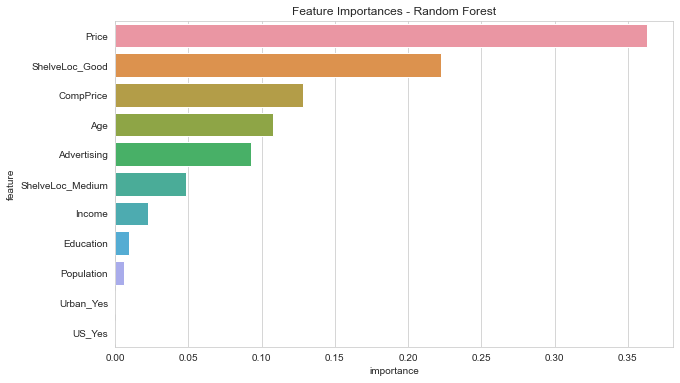

In [26]:
# Create a feature importance for the random forest model
importances = best_model_gbr.feature_importances_

# Create a DataFrame for the feature importances
feature_importances_rf = pd.DataFrame({'feature': X_train.columns, 'importance': importances})

# Sort the DataFrame by importance
feature_importances_rf = feature_importances_rf.sort_values(by='importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importances_rf.head(20))
plt.title('Feature Importances - Random Forest')
plt.show()

In [27]:
feat_importances = pd.Series(
    best_model_gbr.feature_importances_, 
    index=X_train.columns).sort_values(ascending=False)

print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

print("\nTop 3 Most Important Predictors:")
print("-" * 40)
for i, (feature, importance) in enumerate(feat_importances.head(3).items(), 1):
    print(f"{i}. {feature:20s}: {importance:.4f} ({importance*100:.2f}%)")

# Calculate cumulative importance
top_3_cumulative = feat_importances.head(3).sum()
print(f"\nTop 3 features explain {top_3_cumulative*100:.2f}% of total importance")


FEATURE IMPORTANCE ANALYSIS

Top 3 Most Important Predictors:
----------------------------------------
1. Price               : 0.3627 (36.27%)
2. ShelveLoc_Good      : 0.2227 (22.27%)
3. CompPrice           : 0.1280 (12.80%)

Top 3 features explain 71.33% of total importance


<h3><span style="color:red;">Explanation:</span></h3>

#### The x-axis shows the percentage value of each feature’s contribution to the model’s performance.
#### The top 3 predictors are:

1. **Price** - This is by far the most important predictor in the model. It shows that price has the largest impact on car seat sales, holding roughly 35–37% of the total importance. Lower prices likely make the product more attractive to customers, which drives higher sales across stores.

2. **ShelveLoc_Good** - The second most influential variable, contributing around 22% to the model’s performance. A “Good” shelf location means better visibility and accessibility for customers, which naturally increases the likelihood of purchase and boosts sales.

3. **Age** - The competitor’s price holds about 13% importance, showing that stores tend to perform better when their prices are competitive compared to nearby rivals. This highlights the importance of monitoring competitor pricing strategies.

Also, we noticed that **‘US_Yes’ and ‘Urban_Yes’** have near-zero importance, meaning that the store’s geographic location or whether it’s in an urban or rural setting doesn’t significantly influence sales outcomes.

<h1 style="font-family:Arial; font-size:22pt; font-weight:bold; color:#2c3e50;">
d. Compare the two models (5 points)
</h1>

<h3 style="color:#0000FF;">
1.) Create a table comparing MAE, RMSE for both models on validation and test sets.
</h3>


In [28]:
# ===========================================
# RANDOM FOREST vs GRADIENT BOOSTING COMPARISON
# ===========================================

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting'],
    'Validation MAE': [mae_val_rf, mae_val_gbr],
    'Validation RMSE': [rmse_val_rf, rmse_val_gbr],
    'Test MAE': [mae_test_rf, mae_test_gbr],
    'Test RMSE': [rmse_test_rf, rmse_test_gbr]
})

print("\n" + "="*60)
print("MODEL PERFORMANCE COMPARISON")
print("="*60)
display(comparison.round(4))


MODEL PERFORMANCE COMPARISON


,Model,Validation MAE,Validation RMSE,Test MAE,Test RMSE
0,Random Forest,1.4449,1.8941,1.4947,1.7976
1,Gradient Boosting,0.9312,1.1176,1.0113,1.2778


<h3><span style="color:red;">Explanation:</span></h3>

#### Random Forest – The model performed strongly with small and stable errors, but its MAE and RMSE values are slightly higher, meaning it’s a bit less precise in predicting sales compared to Gradient Boosting.

#### Gradient Boosting – This model performed better overall. It achieved lower MAE and RMSE scores on both the validation and test sets, showing that it can make more accurate predictions and handle unseen data more effectively.

#### Overall, both models are performing consistently and give reliable predictions. The differences in their scores suggest that each model has its own strengths where Random Forest is stable and less sensitive to noise, while Gradient Boosting may capture patterns a bit more precisely. 

<h3 style="color:#0000FF;">
2.) Discuss which model performed better and why.
</h3>

In [29]:
if rmse_test_rf < rmse_test_gbr:
    print("\n🏆 Random Forest performs better on the Test Set.")
else:
    print("\n🏆 Gradient Boosting performs better on the Test Set.")


🏆 Gradient Boosting performs better on the Test Set.


<h3><span style="color:red;">Explanation:</span></h3>

#### After comparing the two models, we have concluded that GradientBoosting outperformed RandomForest. 
The reasons are:
1. On both the validation and test sets, GradientBoosting achieved lower MAE and RMSE values.  
2. This indicates that GradientBoosting generalized better and produced more accurate predictions for Sales.  
3. The improvement comes from boosting’s sequential learning,learning from previous errors, which reduces bias by correcting errors made by previous trees. 
4. Gradient Boosting is achieving roughly 30 - 35% lower errors across data. 

#### GradientBoosting performed better than RandomForest in this dataset, as shown by its lower Test MAE (1.0121 vs. 1.4947) and Test RMSE (1.2672 vs. 1.7976).

<h1 style="font-family:Arial; font-size:22pt; font-weight:bold; color:#2c3e50;">
e. Perform error analysis by sales segment using the best model.
</h1>

<h3 style="color:#0000FF;">
1.) Sort the validation set by predicted sales values and split the records into quartiles.
</h3>


In [30]:
# Existing Validation set
X_val.head()

,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_Good,ShelveLoc_Medium,Urban_Yes,US_Yes
285,146,26,11,261,131,39,10,0,1,1,1
289,143,77,25,448,156,43,17,0,1,1,1
141,140,42,0,331,131,28,15,0,0,1,0
220,131,120,15,262,124,30,10,0,1,1,1
103,123,91,0,334,96,78,17,0,0,1,1


In [31]:
y_val_pred = best_model_gbr.predict(X_val)
results = X_val.copy()
results.head()

,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_Good,ShelveLoc_Medium,Urban_Yes,US_Yes
285,146,26,11,261,131,39,10,0,1,1,1
289,143,77,25,448,156,43,17,0,1,1,1
141,140,42,0,331,131,28,15,0,0,1,0
220,131,120,15,262,124,30,10,0,1,1,1
103,123,91,0,334,96,78,17,0,0,1,1


<h3><span style="color:red;">Explanation:</span></h3>

#### First, we used the validation set to check how well the Gradient Boosting model predicts sales, giving 80 predicted values for the 80 samples in X_val.

In [32]:
# Creating a copy to avoid changing or commit errors in the original X_val dataset

results = X_val.copy()
results.head()

,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_Good,ShelveLoc_Medium,Urban_Yes,US_Yes
285,146,26,11,261,131,39,10,0,1,1,1
289,143,77,25,448,156,43,17,0,1,1,1
141,140,42,0,331,131,28,15,0,0,1,0
220,131,120,15,262,124,30,10,0,1,1,1
103,123,91,0,334,96,78,17,0,0,1,1


In [33]:
results['Actual'] = y_val.values
results['Predicted'] = y_val_pred

results = results.sort_values(by='Predicted').reset_index(drop=True)
results.head(10)

,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_Good,ShelveLoc_Medium,Urban_Yes,US_Yes,Actual,Predicted
0,93,91,0,22,117,75,11,0,0,1,0,0.91,1.273479
1,147,58,7,100,191,27,15,0,0,1,1,0.37,2.884149
2,130,28,6,410,133,72,16,0,0,1,1,4.10,2.922384
3,121,86,10,496,145,51,10,0,0,1,1,2.86,3.319172
4,111,25,0,52,121,43,18,0,0,0,0,2.23,3.352435
5,134,48,1,139,145,65,12,0,1,1,1,4.43,3.837793
6,107,79,2,488,103,65,16,0,0,1,0,3.47,4.508340
7,100,79,7,284,95,50,12,0,0,1,1,5.94,4.644118
8,106,46,11,414,96,79,17,0,0,0,0,6.97,4.695765
9,128,46,6,497,138,42,13,0,1,1,0,5.08,4.938696


<h3><span style="color:red;">Explanation:</span></h3>

#### Adding the actual Sales vs the Predicted Sales into the Validation set copy and sorting it from lowest to highest predicted sales.


In [34]:
# Split into quartiles (Q1 = lowest predicted sales, Q4 = highest)
results['Quartile'] = pd.qcut(results['Predicted'], q=4, 
    labels=['Q1 (Lowest Sales)', 'Q2', 'Q3', 'Q4 (Highest Sales)'])
results.head(10)

,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_Good,ShelveLoc_Medium,Urban_Yes,US_Yes,Actual,Predicted,Quartile
0,93,91,0,22,117,75,11,0,0,1,0,0.91,1.273479,Q1 (Lowest Sales)
1,147,58,7,100,191,27,15,0,0,1,1,0.37,2.884149,Q1 (Lowest Sales)
2,130,28,6,410,133,72,16,0,0,1,1,4.10,2.922384,Q1 (Lowest Sales)
3,121,86,10,496,145,51,10,0,0,1,1,2.86,3.319172,Q1 (Lowest Sales)
4,111,25,0,52,121,43,18,0,0,0,0,2.23,3.352435,Q1 (Lowest Sales)
5,134,48,1,139,145,65,12,0,1,1,1,4.43,3.837793,Q1 (Lowest Sales)
6,107,79,2,488,103,65,16,0,0,1,0,3.47,4.508340,Q1 (Lowest Sales)
7,100,79,7,284,95,50,12,0,0,1,1,5.94,4.644118,Q1 (Lowest Sales)
8,106,46,11,414,96,79,17,0,0,0,0,6.97,4.695765,Q1 (Lowest Sales)
9,128,46,6,497,138,42,13,0,1,1,0,5.08,4.938696,Q1 (Lowest Sales)


In [35]:
# Compute residuals (actual - predicted)
results['Residual'] = results['Actual'] - results['Predicted']

# Display first few rows to confirm
results.head(10)

,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_Good,ShelveLoc_Medium,Urban_Yes,US_Yes,Actual,Predicted,Quartile,Residual
0,93,91,0,22,117,75,11,0,0,1,0,0.91,1.273479,Q1 (Lowest Sales),-0.363479
1,147,58,7,100,191,27,15,0,0,1,1,0.37,2.884149,Q1 (Lowest Sales),-2.514149
2,130,28,6,410,133,72,16,0,0,1,1,4.10,2.922384,Q1 (Lowest Sales),1.177616
3,121,86,10,496,145,51,10,0,0,1,1,2.86,3.319172,Q1 (Lowest Sales),-0.459172
4,111,25,0,52,121,43,18,0,0,0,0,2.23,3.352435,Q1 (Lowest Sales),-1.122435
5,134,48,1,139,145,65,12,0,1,1,1,4.43,3.837793,Q1 (Lowest Sales),0.592207
6,107,79,2,488,103,65,16,0,0,1,0,3.47,4.508340,Q1 (Lowest Sales),-1.038340
7,100,79,7,284,95,50,12,0,0,1,1,5.94,4.644118,Q1 (Lowest Sales),1.295882
8,106,46,11,414,96,79,17,0,0,0,0,6.97,4.695765,Q1 (Lowest Sales),2.274235
9,128,46,6,497,138,42,13,0,1,1,0,5.08,4.938696,Q1 (Lowest Sales),0.141304


<h3 style="color:#0000FF;">
2.) For each quartile, calculate the MAE between actual and predicted sales.
</h3>

In [36]:
# Calculate MAE per quartile ---

# Function to compute MAE for a group
def mae_group(group):
    return mean_absolute_error(group['Actual'], group['Predicted'])

# Group by quartile and calculate MAE
mae_by_quartile = results.groupby('Quartile').apply(mae_group).reset_index()
mae_by_quartile.columns = ['Quartile', 'MAE']

# Display the results
mae_by_quartile.round(3)

,Quartile,MAE
0,Q1 (Lowest Sales),0.880
1,Q2,1.147
2,Q3,0.866
3,Q4 (Highest Sales),0.831


<h3 style="color:#0000FF;">
3.) Create a table showing quartile ranges, MAE, and the number of records in each quartile.
</h3>

In [37]:
# ===========================================
# Summary Table: Quartile Range, MAE, Bias, and Record Count
# ===========================================

quartile_bins = pd.qcut(results['Predicted'], q=4)
bin_ranges = [f"[{round(interval.left,3)}, {round(interval.right,3)}]" for interval in quartile_bins.cat.categories]

summary_table = (results.groupby('Quartile').apply(lambda g: pd.Series({
        'Num_Records': g.shape[0],
        'MAE': mean_absolute_error(g['Actual'], g['Predicted']),
        'Bias': g['Residual'].mean()})).reset_index())

summary_table['Quartile_Range'] = bin_ranges
summary_table = summary_table[['Quartile', 'Quartile_Range', 'Num_Records', 'MAE', 'Bias']]
summary_table[['MAE','Bias']] = summary_table[['MAE','Bias']].round(3)

summary_table

,Quartile,Quartile_Range,Num_Records,MAE,Bias
0,Q1 (Lowest Sales),"[1.272, 5.583]",20.0,0.880,0.199
1,Q2,"[5.583, 7.291]",20.0,1.147,0.403
2,Q3,"[7.291, 9.455]",20.0,0.866,0.098
3,Q4 (Highest Sales),"[9.455, 14.862]",20.0,0.831,0.165


<h3 style="color:#0000FF;">
4.) Comment on which quartiles have the lowest and highest errors and explain why the
model may perform better in certain sales ranges.
</h3>

<h3><span style="color:red;">Explanation:</span></h3>

#### Interpretation for Errors by Quartiles of Gradient Boosting Model:

MAE is highest for Second Quartile. 
Q4 Perfoms best 
Q3 has the second lowest MAE.  (0.83)
The model struggles in mid-lower predicted range (Q2).
The model performs better in middle to high ranges which implies it is less suited for lower sales segment.

The error analysis by predicted sales quartile reveals that the model’s performance varies across segments:
- Highest accuracy (lowest MAE and low bias) is observed in the mid-high (Q3) and highest sales segment (Q4), indicating reliable predictions for top-performing sales.
- Largest errors occur in the mid-lower predicted segment (Q2), with systematic underprediction in Q1 and Q2.
- This pattern suggests the model captures high-value sales well but struggles with smaller sales, possibly due to limited examples or non-linearities in the low-sales range.
- The analysis provides guidance for targeted model improvement and helps stakeholders understand where predictions can be trusted versus where caution is needed.

#### Possible reasoning for this behavior:

Regression toward the mean.GB tends to shrink extreme predictions toward the average. This explains why Q1 (lowest sales) is underpredicted and Q3,Q4 (higher sales) are more accurate extreme low values are “pulled up” by the model.

Boosting focuses on reducing overall error.
- It sequentially fits residuals from previous iterations.
- The algorithm prioritizes areas with larger residuals, but the weighting is still global. This can leave smaller sales segments underrepresented, especially if the data distribution is skewed.


#### Possible implications for Sales:
This table also shows how the Gradient Boosting model performs across different sales levels, divided into four quartiles based on predicted sales (from lowest to highest). Each quartile represents 20 validation records.

1. **Q1 (Lowest Sales)** – These stores have the smallest predicted sales (around 1.27 to 5.58 thousand units). The MAE here is 0.88, which means the model is quite accurate even for low-performing stores. The small bias (0.20) shows the model’s predictions are slightly below the actual sales but still close.
2. **Q2 (Mid-Low Sales)** – This group (5.58 to 7.29) has a higher MAE of 1.15 and the largest bias (0.40), meaning the model tends to slightly underpredict sales in this range. This could suggest more variability among stores with moderate sales performance.
3. **Q3 (Mid-High Sales)** – The MAE drops again to 0.87, showing better accuracy. The low bias (0.10) means the model’s predictions are almost perfectly balanced with actual values.
4. **Q4 (Highest Sales)** – These are the top-performing stores (9.45 to 14.86). The model achieves its lowest MAE (0.83), which shows that it predicts high sales values very accurately. The bias (0.17) remains low, meaning no strong tendency to over- or underpredict.

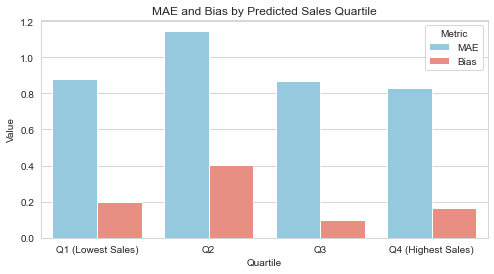

In [38]:
plot_data = summary_table.melt(
    id_vars='Quartile', 
    value_vars=['MAE','Bias'], 
    var_name='Metric', 
    value_name='Value')

# Bar plot
plt.figure(figsize=(8,4))
sns.barplot(x='Quartile', y='Value', hue='Metric', data=plot_data, palette=['skyblue','salmon'])
plt.title('MAE and Bias by Predicted Sales Quartile')
plt.ylabel('Value')
plt.xlabel('Quartile')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)  # For Bias reference
plt.legend(title='Metric')
plt.show()

In [39]:
df_new.head()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education,ShelveLoc_Good,ShelveLoc_Medium,Urban_Yes,US_Yes
0,9.50,138,73,11,276,120,42,17,0,0,1,1
1,11.22,111,48,16,260,83,65,10,1,0,1,1
2,10.06,113,35,10,269,80,59,12,0,1,1,1
3,7.40,117,100,4,466,97,55,14,0,1,1,1
4,4.15,141,64,3,340,128,38,13,0,0,1,0


<h2><span style="color:red;">Overall Conclusion:</span></h2>

#### Both models did a really good job in predicting car seat sales, and the results were quite consistent. Between the two, the Gradient Boosting model performed slightly better because it gave smaller MAE and RMSE values, meaning its predictions were more accurate and stable on new data.

#### From the analysis, we learned that Price, Shelve Location, and Competitor Price are the biggest factors affecting sales. Stores with lower prices and a good shelf placement tend to sell more.

#### The model predicts medium to high sales more accurately but struggles a bit with lower sales ranges, which could be due to fewer examples or more variation in those stores.

#### Overall, both models worked well, and the results give us a clear idea of what drives sales performance. These insights can help guide better decisions around pricing, shelf placement, and marketing efforts to boost sales.
